Check labels

In [1]:
# INbreast_labels_inspect.ipynb
# Cell 1: imports + paths

from pathlib import Path
import pandas as pd

INBREAST_ROOT = Path("data/raw/inbreast")  # adjust if needed

print("INBREAST_ROOT:", INBREAST_ROOT.resolve())
print("Exists?", INBREAST_ROOT.exists())


INBREAST_ROOT: \\wsl$\Ubuntu\home\nabeel\project34\Project34\data\raw\inbreast
Exists? True


In [2]:
# Cell 3: find files + summarise what’s in the folder

from collections import Counter

all_files = [p for p in INBREAST_ROOT.rglob("*") if p.is_file()]
ext_counts = Counter([p.suffix.lower() if p.suffix else "<no_ext>" for p in all_files])

print("Total files:", len(all_files))
print("\nFile type counts (top):")
for ext, cnt in ext_counts.most_common(20):
    print(f"  {ext:10s}  {cnt}")

# DICOM count in ALL-IMGS (if present)
img_dir = INBREAST_ROOT / "ALL-IMGS"
if img_dir.exists():
    dcm_count = len(list(img_dir.rglob("*.dcm")))
    print(f"\nALL-IMGS found. *.dcm count: {dcm_count}")
else:
    print("\nALL-IMGS folder not found under INBREAST_ROOT.")


Total files: 412

File type counts (top):
  .dcm        410
  .xls        1
  .ini        1

ALL-IMGS found. *.dcm count: 410


In [3]:
# Cell 4: find potential label/annotation files (including .xls)

patterns = ("*.xls", "*.xlsx", "*.csv", "*.xml", "*.json", "*.txt")
label_files = []
for pat in patterns:
    label_files.extend(INBREAST_ROOT.rglob(pat))
label_files = sorted(set(label_files))

print("\nPotential label/annotation files found:")
if not label_files:
    print("  (none found under this root)")
else:
    for p in label_files:
        print(" ", p.relative_to(INBREAST_ROOT))



Potential label/annotation files found:
  INbreast.xls


In [4]:
# Cell 2: (optional) install deps from inside the notebook
# If this errors, just run the equivalent in your terminal: python -m pip install pandas xlrd

%pip install -q pandas xlrd


Note: you may need to restart the kernel to use updated packages.


In [5]:
# Cell 5: inspect the .xls (or .xlsx) file(s)

xls_files = [p for p in label_files if p.suffix.lower() in (".xls", ".xlsx")]
if not xls_files:
    print("No .xls/.xlsx files found to inspect.")
else:
    xls_path = xls_files[0]
    print("Inspecting:", xls_path.relative_to(INBREAST_ROOT))

    # Choose engine based on extension
    engine = "xlrd" if xls_path.suffix.lower() == ".xls" else "openpyxl"

    xls = pd.ExcelFile(xls_path, engine=engine)
    print("Sheets:", xls.sheet_names)

    # Read each sheet and print columns + head
    for sheet in xls.sheet_names:
        df = pd.read_excel(xls_path, sheet_name=sheet, engine=engine)
        print(f"\n--- Sheet: {sheet} ---")
        print("Shape:", df.shape)
        print("Columns:", list(df.columns))
        display(df.head(10))


Inspecting: INbreast.xls
Sheets: ['Sheet1', 'Sheet2']

--- Sheet: Sheet1 ---
Shape: (412, 17)
Columns: ['Patient ID', 'Patient age', 'Laterality', 'View', 'Acquisition date', 'File Name', 'ACR', 'Bi-Rads', 'Mass ', 'Micros', 'Distortion', 'Asymmetry', 'Findings Notes (in Portuguese)', 'Other Notes', 'Lesion Annotation Status', 'Pectoral Muscle Annotation', 'Other Annotations']


,Patient ID,Patient age,Laterality,View,Acquisition date,File Name,ACR,Bi-Rads,Mass,Micros,Distortion,Asymmetry,Findings Notes (in Portuguese),Other Notes,Lesion Annotation Status,Pectoral Muscle Annotation,Other Annotations
0,removed,removed,R,CC,201001.0,22678622.0,4,1,NaN,NaN,NaN,NaN,normal,NaN,No annotation (Normal),NaN,NaN
1,removed,removed,L,CC,201001.0,22678646.0,4,3,X,NaN,NaN,NaN,nódulo,NaN,NaN,NaN,NaN
2,removed,removed,R,MLO,201001.0,22678670.0,4,1,NaN,NaN,NaN,NaN,normal,NaN,No annotation (Normal),NaN,NaN
3,removed,removed,L,MLO,201001.0,22678694.0,4,3,X,NaN,NaN,NaN,nódulo,NaN,NaN,NaN,NaN
4,removed,removed,R,CC,201001.0,22614074.0,2,5,X,X,NaN,NaN,nódulo QSE + micros,NaN,NaN,NaN,NaN
5,removed,removed,L,CC,201001.0,22614097.0,2,2,X,X,NaN,NaN,nodulo + micros,NaN,NaN,NaN,NaN
6,removed,removed,R,MLO,201001.0,22614127.0,2,5,X,X,NaN,NaN,nódulo QSE + micros,NaN,NaN,NaN,NaN
7,removed,removed,L,MLO,201001.0,22614150.0,2,2,X,X,NaN,NaN,nódulo + micros,NaN,NaN,NaN,NaN
8,removed,removed,L,MLO,201001.0,50997434.0,3,2,NaN,X,NaN,NaN,micro,NaN,NaN,NaN,NaN
9,removed,removed,R,MLO,201001.0,50997461.0,3,4a,X,X,NaN,NaN,nodulo QSE + micros,NaN,NaN,NaN,NaN



--- Sheet: Sheet2 ---
Shape: (412, 5)
Columns: ['Patient ID', 'Patient age', 'Acquisition date', 'Bi-Rads', 'DG']


,Patient ID,Patient age,Acquisition date,Bi-Rads,DG
0,10455721.0,68.0,20090826.0,2,Ca Invasor
1,10455721.0,68.0,20090826.0,5,NaN
2,10455721.0,68.0,20090826.0,2,NaN
3,10455721.0,68.0,20090826.0,5,NaN
4,10904633.0,64.0,20090825.0,4c,CDIS
5,10904633.0,64.0,20090825.0,4c,NaN
6,11223500.0,64.0,20090525.0,2,NaN
7,11223500.0,64.0,20090525.0,2,NaN
8,11223500.0,64.0,20090525.0,2,NaN
9,11223500.0,64.0,20090525.0,2,NaN


In [9]:
#cell 6
import re
from pathlib import Path
import pandas as pd

IMG_DIR = INBREAST_ROOT / "ALL-IMGS"
dicom_paths = sorted(IMG_DIR.rglob("*.dcm"))

print("IMG_DIR:", IMG_DIR.resolve())
print("DICOM files:", len(dicom_paths))
print("Example filename:", dicom_paths[0].name if dicom_paths else "NONE")

IMG_DIR: \\wsl$\Ubuntu\home\nabeel\project34\Project34\data\raw\inbreast\ALL-IMGS
DICOM files: 410
Example filename: 20586908_6c613a14b80a8591_MG_R_CC_ANON.dcm


Cell 7 — Build mapping: leading numeric ID → DICOM path

In [12]:
def leading_id_from_filename(p: Path):
    m = re.match(r"^(\d+)", p.name)
    return m.group(1) if m else None

id_to_path = {}
bad = 0
for p in dicom_paths:
    k = leading_id_from_filename(p)
    if k is None:
        bad += 1
        continue
    # if duplicates happen, keep the first
    if k not in id_to_path:
        id_to_path[k] = p

print("IDs extracted:", len(id_to_path))
print("Files without leading numeric ID:", bad)

# show a few
for k in list(id_to_path.keys())[:5]:
    print(k, "->", id_to_path[k].name)

IDs extracted: 410
Files without leading numeric ID: 0
20586908 -> 20586908_6c613a14b80a8591_MG_R_CC_ANON.dcm
20586934 -> 20586934_6c613a14b80a8591_MG_L_CC_ANON.dcm
20586960 -> 20586960_6c613a14b80a8591_MG_R_ML_ANON.dcm
20586986 -> 20586986_6c613a14b80a8591_MG_L_ML_ANON.dcm
20587054 -> 20587054_b6a4f750c6df4f90_MG_R_CC_ANON.dcm


Cell 8 — Load Sheet1 and create clean file_id

In [14]:
sheet1 = pd.read_excel(xls_path, sheet_name="Sheet1", engine=engine).copy()

def clean_sheet_file_id(x):
    if pd.isna(x):
        return pd.NA
    return str(int(float(x)))  # 22678622.0 -> "22678622"

sheet1["file_id"] = sheet1["File Name"].apply(clean_sheet_file_id)

print("Sheet1 rows:", len(sheet1))
print("Missing file_id rows:", sheet1["file_id"].isna().sum())

sheet1.head(3)[["File Name","file_id","Laterality","View","ACR","Bi-Rads"]]

Sheet1 rows: 412
Missing file_id rows: 2


,File Name,file_id,Laterality,View,ACR,Bi-Rads
0,22678622.0,22678622,R,CC,4,1
1,22678646.0,22678646,L,CC,4,3
2,22678670.0,22678670,R,MLO,4,1


Cell 9 — DROP the junk tail rows (the NA file_id ones)

In [15]:
before = len(sheet1)
sheet1 = sheet1.dropna(subset=["file_id"]).copy()
after = len(sheet1)

print(f"Dropped {before - after} rows with missing file_id")
print("Rows remaining:", len(sheet1))

Dropped 2 rows with missing file_id
Rows remaining: 410


Cell 10 — Join Sheet1 to DICOM paths

In [16]:
sheet1["dicom_path"] = sheet1["file_id"].map(id_to_path)

matched = sheet1["dicom_path"].notna().sum()
unmatched = sheet1["dicom_path"].isna().sum()

print("Matched to DICOM:", matched)
print("Unmatched:", unmatched)

# show a few unmatched (should be small, maybe 0)
sheet1.loc[sheet1["dicom_path"].isna(), ["File Name","file_id","Laterality","View","ACR","Bi-Rads"]].head(10)

Matched to DICOM: 410
Unmatched: 0


,File Name,file_id,Laterality,View,ACR,Bi-Rads


Cell 11 — Check duplicates properly (now that NA rows are gone)

In [17]:
dup_ids = sheet1["file_id"].duplicated(keep=False)
print("Duplicate file_id rows (real duplicates):", dup_ids.sum())

if dup_ids.any():
    display(sheet1.loc[dup_ids, ["file_id","Laterality","View","ACR","Bi-Rads"]].sort_values("file_id").head(30))

Duplicate file_id rows (real duplicates): 0


Cell 12 — Create final matched dataframe + clean ACR + create tissue label

In [18]:
df = sheet1[sheet1["dicom_path"].notna()].copy()

# keep one row per image if duplicates exist
df = df.drop_duplicates(subset=["file_id"], keep="first").copy()

# Clean ACR
df["ACR"] = pd.to_numeric(df["ACR"], errors="coerce")

# keep only valid ACR rows
df = df[df["ACR"].isin([1,2,3,4])].copy()

# Binary tissue label: 0 (ACR 1-2) non-dense, 1 (ACR 3-4) dense
df["tissue_binary"] = df["ACR"].map(lambda a: 1 if a >= 3 else 0)

print("Final usable rows:", len(df))
print("\nACR distribution:")
display(df["ACR"].value_counts(dropna=False).sort_index())

print("\ntissue_binary distribution (0 non-dense, 1 dense):")
display(df["tissue_binary"].value_counts(dropna=False))

Final usable rows: 409

ACR distribution:


ACR
1.0    136
2.0    146
3.0     99
4.0     28
Name: count, dtype: int64


tissue_binary distribution (0 non-dense, 1 dense):


tissue_binary
0    282
1    127
Name: count, dtype: int64

Cell 13 — Save data/processed/inbreast_index.csv

In [19]:
OUT_DIR = Path("data/processed")
OUT_DIR.mkdir(parents=True, exist_ok=True)

out = df[[
    "file_id", "dicom_path",
    "Patient ID", "Patient age",
    "Laterality", "View", "Acquisition date",
    "ACR", "tissue_binary",
    "Bi-Rads",
    "Mass ", "Micros", "Distortion", "Asymmetry",
    "Lesion Annotation Status"
]].copy()

out["dicom_path"] = out["dicom_path"].astype(str)

out_path = OUT_DIR / "inbreast_index.csv"
out.to_csv(out_path, index=False)

print("Saved:", out_path.resolve())
out.head(5)

Saved: \\wsl$\Ubuntu\home\nabeel\project34\Project34\data\processed\inbreast_index.csv


,file_id,dicom_path,Patient ID,Patient age,Laterality,View,Acquisition date,ACR,tissue_binary,Bi-Rads,Mass,Micros,Distortion,Asymmetry,Lesion Annotation Status
0,22678622,data\raw\inbreast\ALL-IMGS\22678622_61b13c59bc...,removed,removed,R,CC,201001.0,4.0,1,1,NaN,NaN,NaN,NaN,No annotation (Normal)
1,22678646,data\raw\inbreast\ALL-IMGS\22678646_61b13c59bc...,removed,removed,L,CC,201001.0,4.0,1,3,X,NaN,NaN,NaN,NaN
2,22678670,data\raw\inbreast\ALL-IMGS\22678670_61b13c59bc...,removed,removed,R,MLO,201001.0,4.0,1,1,NaN,NaN,NaN,NaN,No annotation (Normal)
3,22678694,data\raw\inbreast\ALL-IMGS\22678694_61b13c59bc...,removed,removed,L,MLO,201001.0,4.0,1,3,X,NaN,NaN,NaN,NaN
4,22614074,data\raw\inbreast\ALL-IMGS\22614074_6bd24a0a42...,removed,removed,R,CC,201001.0,2.0,0,5,X,X,NaN,NaN,NaN


Cell 14 — Sanity plot: 6 random images with their labels

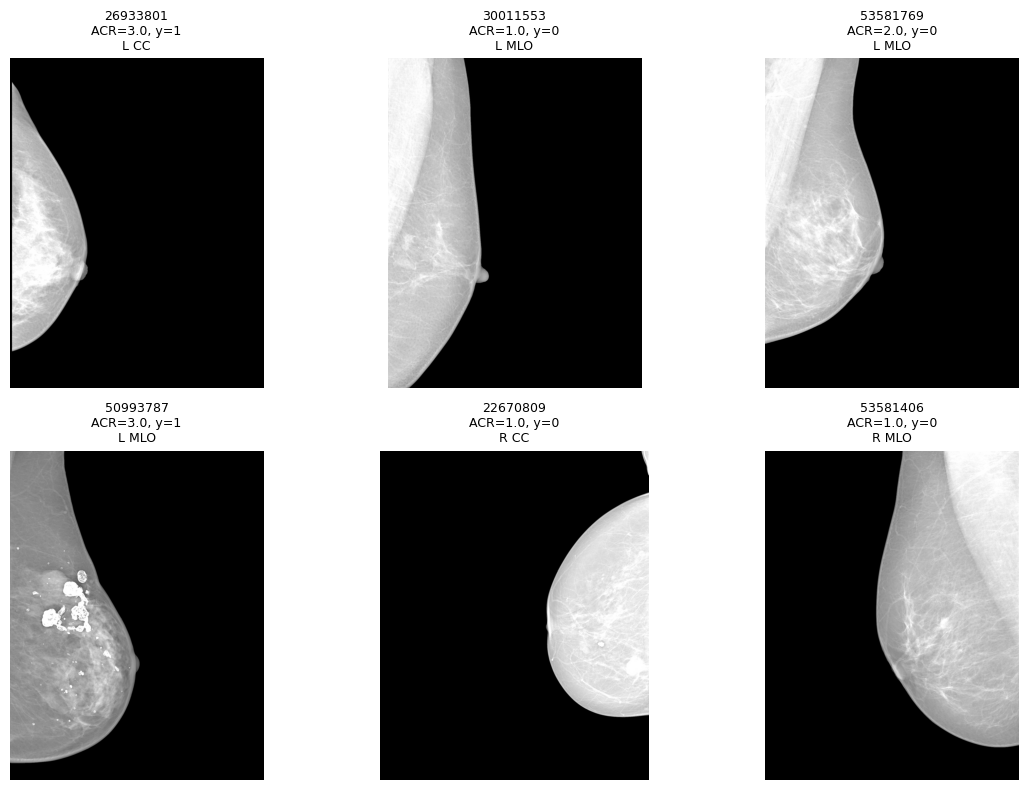

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import pydicom
from pydicom.pixel_data_handlers.util import apply_voi_lut

def load_dicom_for_view(path: Path) -> np.ndarray:
    ds = pydicom.dcmread(str(path))
    img = ds.pixel_array.astype(np.float32)

    try:
        img = apply_voi_lut(img, ds).astype(np.float32)
    except Exception:
        pass

    if getattr(ds, "PhotometricInterpretation", "") == "MONOCHROME1":
        img = img.max() - img

    lo, hi = np.percentile(img, (1, 99))
    img = np.clip(img, lo, hi)
    img = (img - lo) / (hi - lo + 1e-8)
    return img

sample = out.sample(n=min(6, len(out)), random_state=42)

plt.figure(figsize=(12, 8))
for i, row in enumerate(sample.itertuples(index=False), 1):
    img = load_dicom_for_view(Path(row.dicom_path))
    plt.subplot(2, 3, i)
    plt.imshow(img, cmap="gray")
    plt.title(f"{row.file_id}\nACR={row.ACR}, y={row.tissue_binary}\n{row.Laterality} {row.View}", fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()